In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import seaborn as sns


In [2]:
#pip install xgboost
from google.colab import files
uploaded = files.upload()

Saving Data_PEI_2019-2023.xlsx to Data_PEI_2019-2023.xlsx


In [10]:

# Load the dataset
df1 = pd.read_excel("Data_PEI_2019-2023.xlsx")



In [11]:
df1.head()

,Province,Location,Week Number,Crop Disease,Spore Trapping,DSI,Date,Year,Month,Temp,Dew Point Temp,Rel Hum,Precipitation,Wind Dir,Wind Spd
0,PEI,Field 2,29,Early Blight,16,1,2019-07-21,2019,7,19.786310,16.335714,81.339286,0.0,22.482143,17.892857
1,PEI,Field 2,29,Gray Mold,0,0,2019-07-21,2019,7,19.786310,16.335714,81.339286,0.0,22.482143,17.892857
2,PEI,Field 2,30,Early Blight,16,1,2019-07-28,2019,7,20.357738,15.748214,75.809524,0.0,21.416667,14.607143
3,PEI,Field 2,30,Gray Mold,0,0,2019-07-28,2019,7,20.357738,15.748214,75.809524,0.0,21.416667,14.607143
4,PEI,Field 2,31,Early Blight,49,1,2019-08-04,2019,8,22.401786,17.655357,75.333333,0.0,23.351190,18.976190


In [12]:
df1 = df1[df1['Crop Disease'] == 'Early Blight']

In [13]:
# Encode categorical variables
df1['Crop Disease'] = df1['Crop Disease'].astype("category").cat.codes
df1['Location'] = df1['Location'].astype("category").cat.codes


In [14]:

# Ensure the "Date" column is valid for conversion
df1["Date"] = pd.to_datetime(df1["Date"], errors='coerce')
if df1["Date"].isna().any():
    print("Invalid dates found:")
    print(df1[df1["Date"].isna()])



Class distribution in target variable:
DSI
1    519
0    222
Name: count, dtype: int64


<Axes: xlabel='DSI', ylabel='count'>

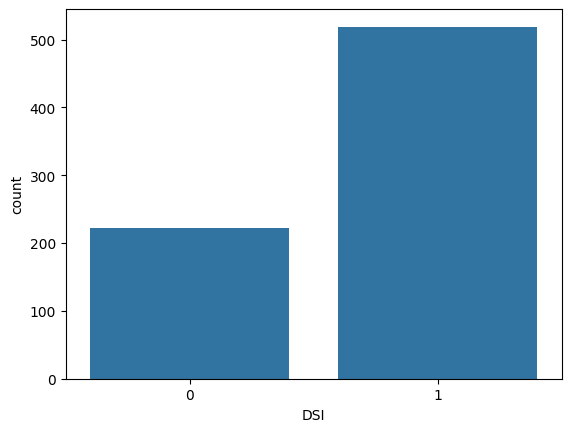

In [15]:
# Drop the "Date" column
df1 = df1.drop(["Date"], axis=1)

# Separate features and target variable
X = df1.drop(['DSI', 'Province',"Spore Trapping", 'Crop Disease','Year'], axis=1)
y = df1['DSI']

# Check class distribution
print("Class distribution in target variable:")
print(y.value_counts())
sns.countplot(x=y)



In [ ]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify shapes
print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

# Standard scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


Training data: (592, 9), Testing data: (149, 9)


In [ ]:

# Random Forest Classifier (baseline)
r = RandomForestClassifier(random_state=42,max_features = None, n_estimators=1000)
r.fit(X_train, y_train)
y_pred = r.predict(X_test)



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70        48
           1       0.84      0.90      0.87       101

    accuracy                           0.82       149
   macro avg       0.80      0.77      0.78       149
weighted avg       0.81      0.82      0.81       149

Confusion Matrix (Random Forest):


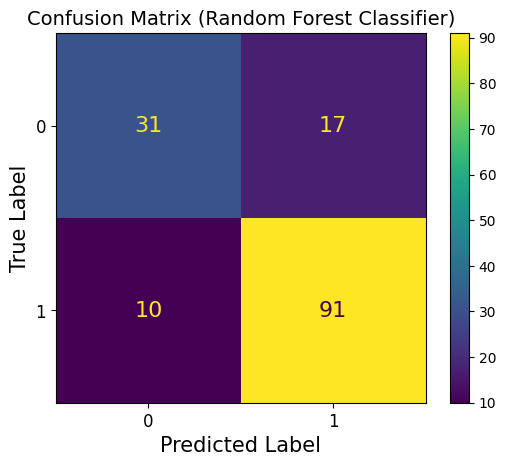

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# # Initialize and train Random Forest
# rf_model = RandomForestClassifier(random_state=42)
# rf_model.fit(X_train, y_train)

# # Make predictions
# y_pred_rf = rf_model.predict(X_test)

# Evaluation: Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix (Random Forest):")
cm_rf = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix (Random Forest Classifier)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
for labels in disp_rf.text_:
  for label in labels:
    label.set_fontsize(16)

plt.show()



In [ ]:
disease_accuracy = accuracy_score(y_test, y_pred)
print(disease_accuracy)
from sklearn.metrics import precision_score, recall_score, f1_score
disease_precision = precision_score(y_test, y_pred, average='binary')
print(f"Precision: {disease_precision}")
disease_recall = recall_score(y_test, y_pred, average='binary')
print(f"Recall: {disease_recall}")
disease_f1 = f1_score(y_test, y_pred, average='binary')
print(f"F1-Score: {disease_f1}")

0.8187919463087249
Precision: 0.8425925925925926
Recall: 0.900990099009901
F1-Score: 0.8708133971291866


          Feature  Importance
0        Location    0.164466
6   Precipitation    0.158207
3            Temp    0.147032
4  Dew Point Temp    0.118796
5         Rel Hum    0.104782
7        Wind Dir    0.104094
1     Week Number    0.095280
8        Wind Spd    0.094392
2           Month    0.012952


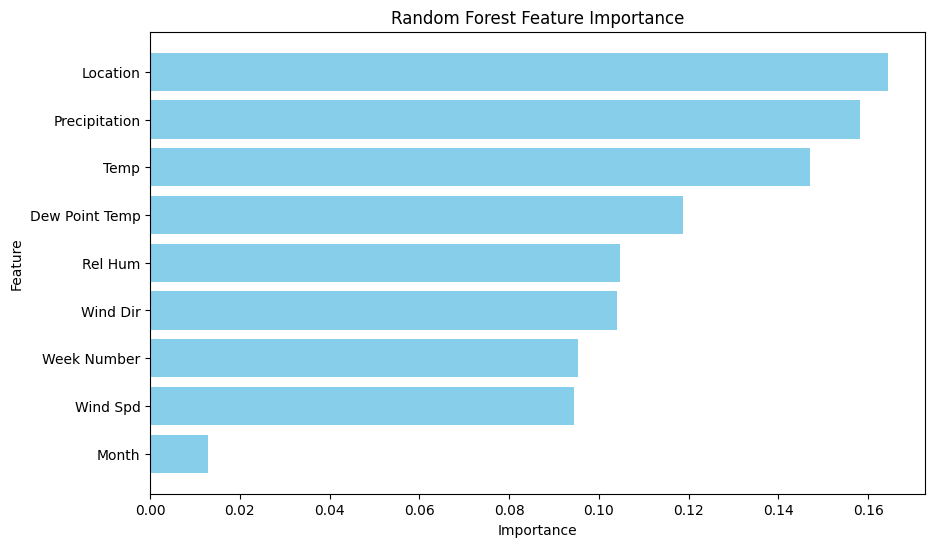

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = r.feature_importances_
feature_names = X.columns  # your selected 11 features

# Create DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print table
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.show()


In [ ]:

# Hyperparameter tuning for XGBoost
from sklearn.model_selection import GridSearchCV
# param grid: defines the hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300], #number of trees in XGboost
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1, 2]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1  #n_jobs=-1: Utilizes all available CPU cores for parallel processing.
)
grid_search.fit(X_train, y_train)
print("Best Parameters (XGBoost):", grid_search.best_params_)



Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best Parameters (XGBoost): {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2, 'subsample': 0.8}


In [ ]:
# Train XGBoost with best parameters
xgb = XGBClassifier(random_state=42, **grid_search.best_params_)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)



XGBoost Accuracy: 0.8053691275167785
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.48      0.61        48
           1       0.80      0.96      0.87       101

    accuracy                           0.81       149
   macro avg       0.82      0.72      0.74       149
weighted avg       0.81      0.81      0.79       149



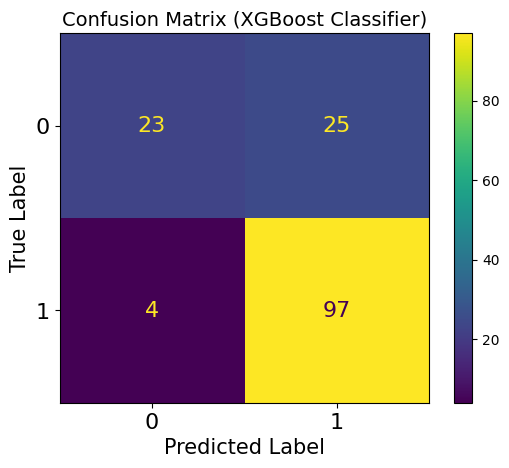

In [ ]:
# Evaluation: XGBoost
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("Confusion Matrix (XGBoost Classifier)", fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
for labels in disp_xgb.text_:
  for label in labels:
    label.set_fontsize(16)

plt.show()

          Feature  Importance
6   Precipitation    0.161930
3            Temp    0.152845
1     Week Number    0.147286
5         Rel Hum    0.100113
4  Dew Point Temp    0.098510
2           Month    0.093200
8        Wind Spd    0.086148
0        Location    0.082846
7        Wind Dir    0.077122


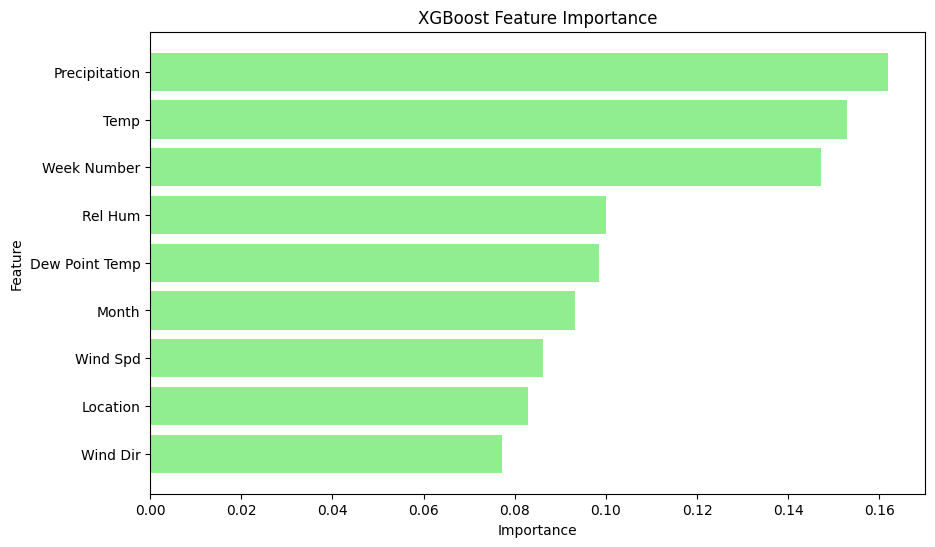

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importances = xgb.feature_importances_
feature_names = X.columns  # your 11 features

# Create a DataFrame
xgb_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)
print(xgb_importance_df)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(xgb_importance_df['Feature'], xgb_importance_df['Importance'], color='lightgreen')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()


In [ ]:

# Cross-validation with stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy (XGBoost):", cv_scores.mean())


Cross-Validation Accuracy (XGBoost): 0.765218574278977


In [ ]:
cv_scores = cross_val_score(r, X, y, cv=skf, scoring='accuracy')
print("Cross-Validation Accuracy (random):", cv_scores.mean())

Cross-Validation Accuracy (random): 0.7409577362597497


<Figure size 1000x800 with 0 Axes>

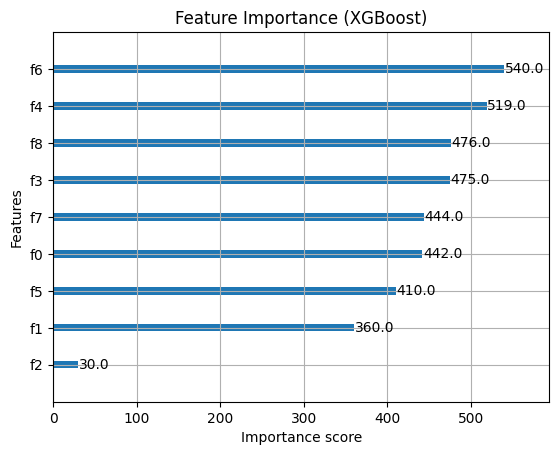

In [ ]:

# Feature importance visualization (XGBoost)
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(xgb)
plt.title("Feature Importance (XGBoost)")
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression



GaussianNB Classifier:
TSImple Model est Accuracy: 0.7114
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.35      0.44        48
           1       0.74      0.88      0.81       101

    accuracy                           0.71       149
   macro avg       0.66      0.62      0.62       149
weighted avg       0.69      0.71      0.69       149



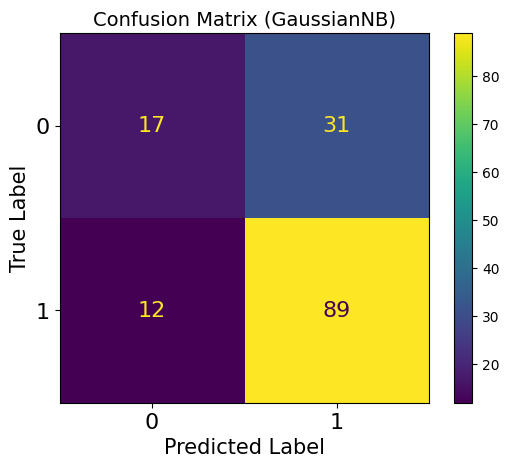

accuracy 0.7114093959731543
Cross-Validation Precision: 0.7416666666666667
Cross-Validation Recall: 0.8811881188118812
Cross-Validation F1-Score: 0.8054298642533937
Cross-Validation Metrics (5 folds):
Accuracy: 0.6950 ± 0.0385

KNeighborsClassifier Classifier:
TSImple Model est Accuracy: 0.7047
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.46      0.50        48
           1       0.76      0.82      0.79       101

    accuracy                           0.70       149
   macro avg       0.66      0.64      0.65       149
weighted avg       0.69      0.70      0.70       149



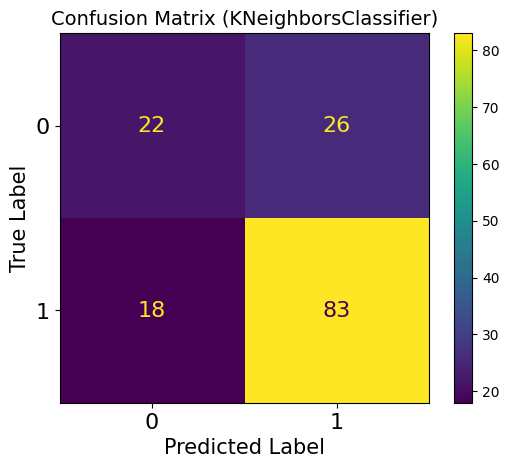

accuracy 0.7046979865771812
Cross-Validation Precision: 0.7614678899082569
Cross-Validation Recall: 0.8217821782178217
Cross-Validation F1-Score: 0.7904761904761904
Cross-Validation Metrics (5 folds):
Accuracy: 0.7058 ± 0.0283

Decision Tree Classifier Classifier:
TSImple Model est Accuracy: 0.7919
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.75      0.70        48
           1       0.87      0.81      0.84       101

    accuracy                           0.79       149
   macro avg       0.76      0.78      0.77       149
weighted avg       0.80      0.79      0.80       149



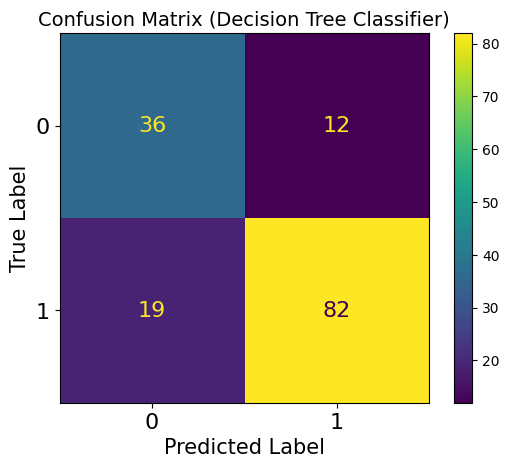

accuracy 0.7919463087248322
Cross-Validation Precision: 0.8723404255319149
Cross-Validation Recall: 0.8118811881188119
Cross-Validation F1-Score: 0.841025641025641
Cross-Validation Metrics (5 folds):
Accuracy: 0.7220 ± 0.0352

LogisticRegression Classifier:
TSImple Model est Accuracy: 0.6779
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.15      0.23        48
           1       0.70      0.93      0.80       101

    accuracy                           0.68       149
   macro avg       0.60      0.54      0.51       149
weighted avg       0.63      0.68      0.61       149



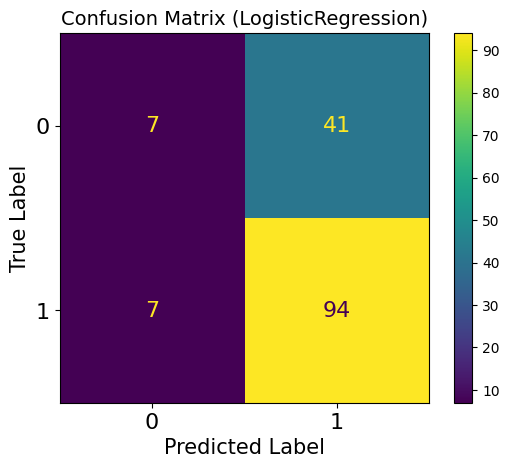

accuracy 0.6778523489932886
Cross-Validation Precision: 0.6962962962962963
Cross-Validation Recall: 0.9306930693069307
Cross-Validation F1-Score: 0.7966101694915254
Cross-Validation Metrics (5 folds):
Accuracy: 0.7058 ± 0.0193


In [ ]:

# Initialize classifiers
gnb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)  # Default: 5 neighbors
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

# List of classifiers for iteration
classifiers = {
    "GaussianNB": gnb,
    "KNeighborsClassifier": knn,
    "Decision Tree Classifier": dt,
    "LogisticRegression": lr
}

# Number of cross-validation folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Train, evaluate, and perform cross-validation for each classifier
for name, clf in classifiers.items():
    print(f"\n{name} Classifier:")

    # Train the classifier
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Accuracy and classification report
    print(f"TSImple Model est Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name})", fontsize=14)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Predicted Label", fontsize=15)
    plt.ylabel("True Label", fontsize=15)

    # Adjust inside label font size
    for labels in disp.text_:  # Update text labels
        for label in labels:
            label.set_fontsize(16)
    # plt.show()
     # Confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
    # disp.plot(ax=ax, cmap='viridis', colorbar=False)
    # plt.title(f"Confusion Matrix ({name})", fontsize=16)
    # plt.xticks(fontsize=14)
    # plt.yticks(fontsize=14)

    # # Adjust inside label font size
    # for labels in disp.text_:  # Update text labels
    #     for label in labels:
    #         label.set_fontsize(18)



    plt.show()

    disease_accuracy = accuracy_score(y_test, y_pred)
    print("accuracy", disease_accuracy)
    # Precision, Recall, and F1-Score without cross-validation
    precision_scores = precision_score(y_test, y_pred, average='binary')
    print("Cross-Validation Precision:", precision_scores)

    recall_scores = recall_score(y_test, y_pred, average='binary')
    print("Cross-Validation Recall:", recall_scores)

    f1_scores = f1_score(y_test, y_pred, average='binary')
    print("Cross-Validation F1-Score:", f1_scores)

    # Perform cross-validation for multiple metrics
    accuracy_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    print(f"Cross-Validation Metrics ({n_splits} folds):")
    print(f"Accuracy: {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")

          Feature  Importance
0        Location    0.210084
3            Temp    0.190967
6   Precipitation    0.178326
7        Wind Dir    0.100902
4  Dew Point Temp    0.098743
1     Week Number    0.072006
5         Rel Hum    0.070151
8        Wind Spd    0.065713
2           Month    0.013109


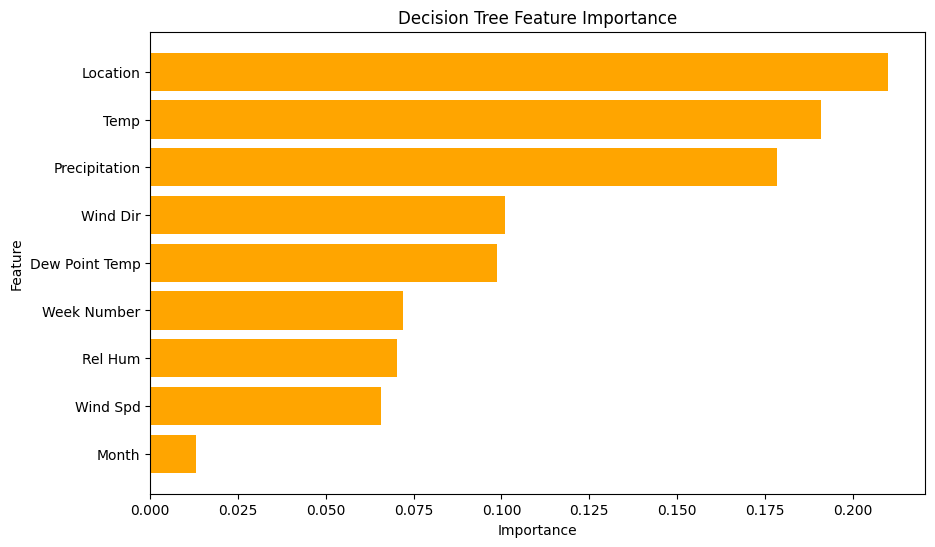

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Fit the Decision Tree (if not already fitted)
dt.fit(X_train, y_train)

# Get feature importance
importances = dt.feature_importances_
feature_names = X.columns  # your selected features

# Create DataFrame
dt_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
dt_importance_df = dt_importance_df.sort_values(by='Importance', ascending=False)
print(dt_importance_df)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(dt_importance_df['Feature'], dt_importance_df['Importance'], color='orange')
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importance')
plt.show()



GaussianNB Classifier:
TSImple Model est Accuracy: 0.7114
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.35      0.44        48
           1       0.74      0.88      0.81       101

    accuracy                           0.71       149
   macro avg       0.66      0.62      0.62       149
weighted avg       0.69      0.71      0.69       149



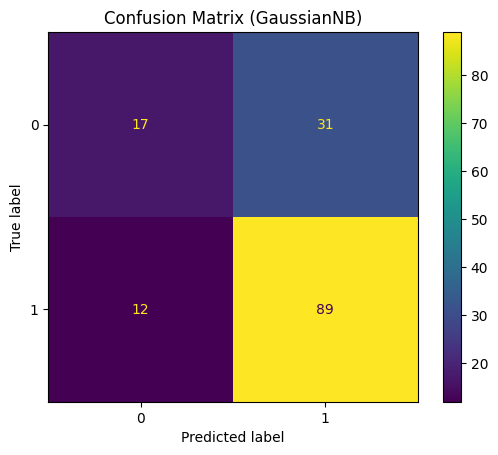

Cross-Validation Accuracy (5 folds): 0.7031 ± 0.0434

KNeighborsClassifier Classifier:
TSImple Model est Accuracy: 0.7450
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.50      0.56        48
           1       0.78      0.86      0.82       101

    accuracy                           0.74       149
   macro avg       0.71      0.68      0.69       149
weighted avg       0.73      0.74      0.74       149



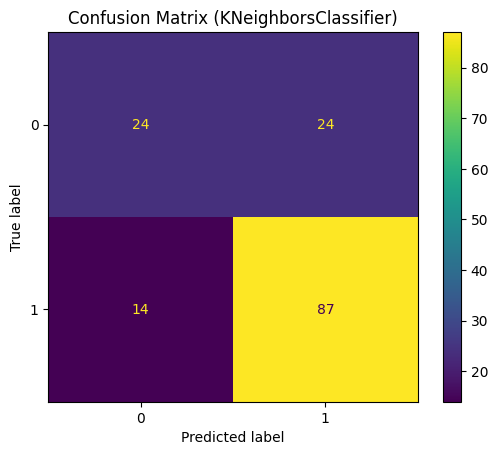

Cross-Validation Accuracy (5 folds): 0.7126 ± 0.0272

DecisionTreeClassifier Classifier:
TSImple Model est Accuracy: 0.8054
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.75      0.71        48
           1       0.88      0.83      0.85       101

    accuracy                           0.81       149
   macro avg       0.78      0.79      0.78       149
weighted avg       0.81      0.81      0.81       149



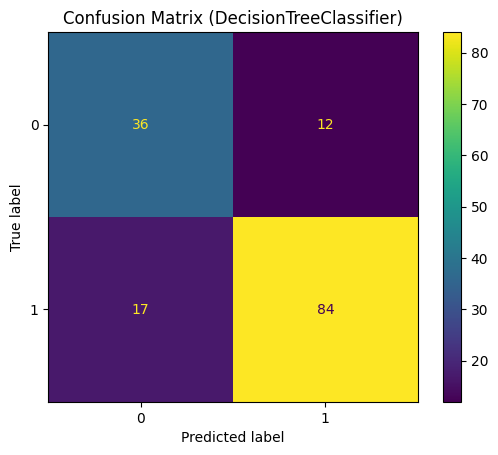

Cross-Validation Accuracy (5 folds): 0.7180 ± 0.0402

LogisticRegression Classifier:
TSImple Model est Accuracy: 0.6980
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.23      0.33        48
           1       0.72      0.92      0.81       101

    accuracy                           0.70       149
   macro avg       0.65      0.57      0.57       149
weighted avg       0.67      0.70      0.65       149



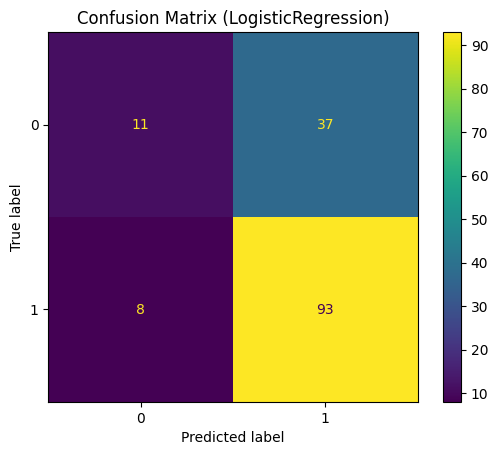

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross-Validation Accuracy (5 folds): 0.7044 ± 0.0181


In [ ]:

# Initialize classifiers
gnb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)  # Default: 5 neighbors

dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

# List of classifiers for iteration
classifiers = {
    "GaussianNB": gnb,
    "KNeighborsClassifier": knn,
    "DecisionTreeClassifier": dt,
    "LogisticRegression": lr
}

# Number of cross-validation folds
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Train, evaluate, and perform cross-validation for each classifier
for name, clf in classifiers.items():
    print(f"\n{name} Classifier:")

    # Train the classifier
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Accuracy and classification report
    print(f"TSImple Model est Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name})")
    plt.show()

    # Perform cross-validation
    cv_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    print(f"Cross-Validation Accuracy ({n_splits} folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
